<a href="https://colab.research.google.com/github/ChotanSharma/CIS350-HW2-SHARMA/blob/main/chotan_sharma(Kmeans).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
files.upload()

Saving Mall_Customers_Segmentation.csv to Mall_Customers_Segmentation.csv


{'Mall_Customers_Segmentation.csv': b'CustomerID,Age,Annual Income (k$),Spending Score (1-100)\r\n1,19,15,39\r\n2,21,15,81\r\n3,20,16,6\r\n4,23,16,77\r\n5,31,17,40\r\n6,22,17,76\r\n7,35,18,6\r\n8,23,18,94\r\n9,64,19,3\r\n10,30,19,72\r\n11,67,19,14\r\n12,35,19,99\r\n13,58,20,15\r\n14,24,20,77\r\n15,37,20,13\r\n16,22,20,79\r\n17,35,21,35\r\n18,20,21,66\r\n19,52,23,29\r\n20,35,23,98\r\n21,35,24,35\r\n22,25,24,73\r\n23,46,25,5\r\n24,31,25,73\r\n25,54,28,14\r\n26,29,28,82\r\n27,45,28,32\r\n28,35,28,61\r\n29,40,29,31\r\n30,23,29,87\r\n31,60,30,4\r\n32,21,30,73\r\n33,53,33,4\r\n34,18,33,92\r\n35,49,33,14\r\n36,21,33,81\r\n37,42,34,17\r\n38,30,34,73\r\n39,36,37,26\r\n40,20,37,75\r\n41,65,38,35\r\n42,24,38,92\r\n43,48,39,36\r\n44,31,39,61\r\n45,49,39,28\r\n46,24,39,65\r\n47,50,40,55\r\n48,27,40,47\r\n49,29,40,42\r\n50,31,40,42\r\n51,49,42,52\r\n52,33,42,60\r\n53,31,43,54\r\n54,59,43,60\r\n55,50,43,45\r\n56,47,43,41\r\n57,51,44,50\r\n58,69,44,46\r\n59,27,46,51\r\n60,53,46,46\r\n61,70,46,56\r\n62

In [3]:
import pandas as pd
df = pd.read_csv('Mall_Customers_Segmentation.csv')
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40


In [6]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
# Step 2: Normalize the data
# Use MinMaxScaler to normalize the data
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(df)
normalized_df = pd.DataFrame(normalized_data, columns=['CustomerId', 'Age', 'Annual Income', 'Spending Score'])
normalized_df.head()

,CustomerId,Age,Annual Income,Spending Score
0,0.000000,0.019231,0.000000,0.387755
1,0.005025,0.057692,0.000000,0.816327
2,0.010050,0.038462,0.008197,0.051020
3,0.015075,0.096154,0.008197,0.775510
4,0.020101,0.250000,0.016393,0.397959


In [13]:
#code to inspect column name
print(df.columns.tolist())

['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


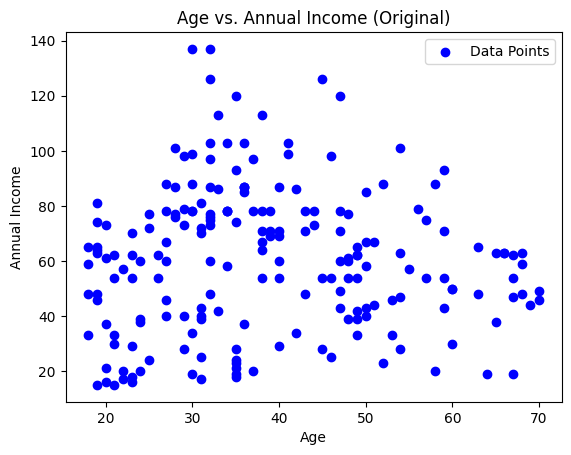

In [14]:
# Step 3: Visualize the original dataset
# Scatter plot to show the data points
plt.scatter(df['Age'], df['Annual Income (k$)'], c='blue', label='Data Points')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.title('Age vs. Annual Income (Original)')
plt.legend()
plt.show()

In [16]:
#code to inspect column name
print(normalized_df.columns.tolist())

['CustomerId', 'Age', 'Annual Income', 'Spending Score']


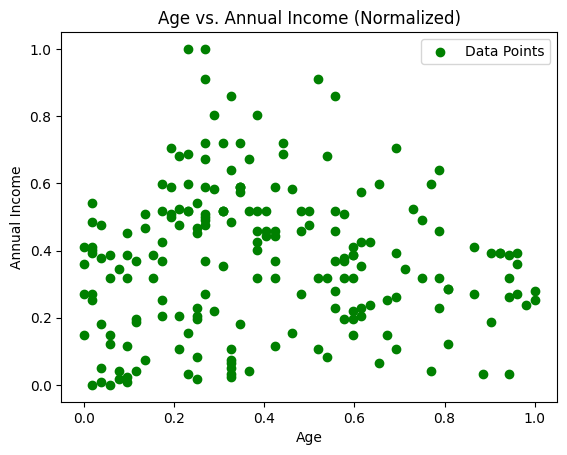

In [17]:
# Step 3: Visualize the normalized dataset
# Scatter plot to show the data points
plt.scatter(normalized_df['Age'], normalized_df['Annual Income'], c='green', label='Data Points')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.title('Age vs. Annual Income (Normalized)')
plt.legend()
plt.show()

In [18]:
# Step 4: Apply KMeans clustering with different numbers of clusters
# Initializing lists to store results for evaluation

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


k_values = [2, 3, 4]
silhouette_scores = []

# Iterate through different k values to evaluate the clustering
for k in k_values:
    # Initialize the KMeans model with k clusters
    kmeans = KMeans(n_clusters=k, random_state=42)

    # Fit the model to the normalized data
    kmeans.fit(normalized_df)

    # Predict cluster labels
    cluster_labels = kmeans.labels_

    # Calculate the Silhouette score
    score = silhouette_score(normalized_df, cluster_labels)
    silhouette_scores.append(score)

    print(f"For k = {k}, Silhouette Score = {score:.2f}")


For k = 2, Silhouette Score = 0.32
For k = 3, Silhouette Score = 0.34
For k = 4, Silhouette Score = 0.42


In [20]:
# Step 5: Select the best k based on Silhouette score
import numpy as np
best_k = k_values[np.argmax(silhouette_scores)]
print(f"\nThe best number of clusters is k = {best_k} with a Silhouette Score of {max(silhouette_scores):.2f}.")


The best number of clusters is k = 4 with a Silhouette Score of 0.42.


In [51]:
# Step 6: Apply KMeans with the best k and analyze the clusters
# Initialize the KMeans model with the best k
kmeans_best = KMeans(n_clusters=best_k, random_state=42)
kmeans_best.fit(df)
cluster_labels = kmeans_best.labels_
cluster_labels

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [53]:
# Add the cluster labels to the original DataFrame for the dataset
df['Cluster'] = cluster_labels

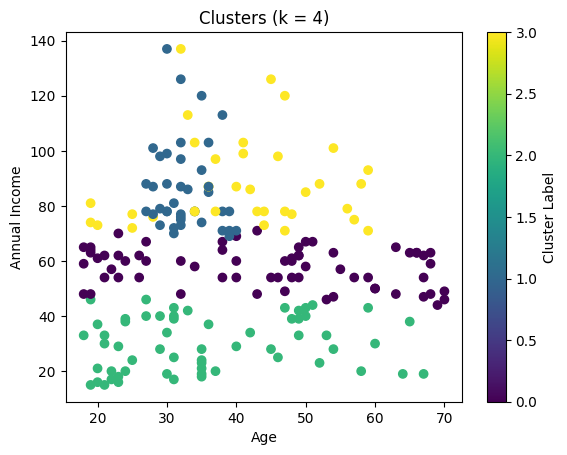

In [54]:
# Visualize the clusters
import matplotlib.pyplot as plt
plt.scatter(df['Age'], df['Annual Income (k$)'], c=df['Cluster'], cmap='viridis', label='cluster')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.title(f'Clusters (k = {best_k})')
plt.colorbar(label='Cluster Label')
plt.show()

In [55]:
# Step 7: Analyze the clusters for insights
# Group by the clusters and calculate the mean of features for each cluster
cluster_analysis = df.groupby('Cluster').mean()
print("\nCluster Analysis (Average Age and Income for each cluster):")
print(cluster_analysis)


Cluster Analysis (Average Age and Income for each cluster):
         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         92.484848  43.878788           57.727273               49.257576
1        162.000000  32.692308           86.538462               82.128205
2         30.067797  36.101695           29.864407               49.864407
3        164.000000  40.805556           87.916667               17.888889


In [7]:
!pip install numpy==1.26.4  pyyaml


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 79.3 MB/s eta 0:00:00
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/commands/install.py", line 447, in run
    conflicts = self._determine_conflicts(to_install)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/pip/_internal/commands/install.py", line 578, in _determine_conflicts
    return check_install_conflicts(to_install)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [8]:
!pip install numpy==1.26.4  pyyaml

  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


In [16]:
!pip install scikit-learn-extra

In [18]:
# Step 1: Downgrade NumPy to a compatible version
!pip install numpy==1.24.4 --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 79.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
blosc2 3.2.1 requires numpy>=1.26, but you have numpy 1.24.4 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
pymc 5.21.1 requires numpy>=1.25.0, but you have numpy 1.24.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.24.4 which is incompatible.
treescope 0.1.9 requires numpy>=1.25.2, but you have numpy 1.24.4 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.


In [2]:
import numpy
print("NumPy version:", numpy.__version__)

from sklearn_extra.cluster import KMedoids
print("KMedoids imported successfully!")

NumPy version: 1.24.4
KMedoids imported successfully!


In [3]:
from sklearn_extra.cluster import KMedoids
model = KMedoids(n_clusters=2, random_state=0).fit(df)

yhat = model.fit_predict(df)

clusters = unique(yhat)
for cluster in clusters:
  row_ix = where(yhat==cluster)
  pyplot.scatter(X[row_ix, 0], X[row_ix, 1])

pyplot.show()

NameError: name 'df' is not defined